<p align="center">
  <img src="assets/MIXTUREOFEXPERT.jpg" alt="Mixture of Experts" width="600"/>
</p>

In [17]:
# Fix for macOS OpenMP library conflict (prevents kernel crash)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

### 🔥 Deep Learning Cave — Chapter 6: The Expert's Council Chamber

```
                    🏛️ THE EXPERT'S COUNCIL CHAMBER 🏛️
                           
     ┌─────────────────────────────────────────────────┐
     │  You've journeyed through:                      │
     │  ✓ PyTorch Fundamentals Chamber                 │
     │  ✓ Classic Transformer Hall                     │
     │  ✓ Modern LLaMA Archives                        │
     │  ✓ Vision Transformer Gallery                   │
     │  ✓ JEPA Self-Supervised Sanctum                 │
     │                                                  │
     │  🎯 NOW: The Expert's Council Chamber           │
     │     Where Specialists Convene                   │
     └─────────────────────────────────────────────────┘

     In this chamber, you'll discover:
     🧠 The art of SPARSE COMPUTATION
     🎭 How experts SPECIALIZE in different domains
     🔀 DYNAMIC ROUTING that activates the right expert
     ⚖️ LOAD BALANCING to keep all experts engaged
     
     Welcome to Mixture of Experts (MoE) — where models
     learn to consult the right specialist for every problem.
```

### 📚 Learning Path: The Expert's Council

| Part | Component | What You'll Build | Time |
|------|-----------|-------------------|------|
| **1** | **Setup & Data** | Multi-domain dataset (News + Reviews) | 10 min |
| **2** | **MoE Fundamentals** | Understanding sparse computation | 15 min |
| **3** | **Simple Switch MoE** | 4-expert Top-1 routing (Google, 2021) | 25 min |
| **4** | **Advanced Mixtral** | Top-2 routing (Mistral AI, 2023) | 20 min |
| **5** | **Complete Model** | MoE Transformer with training loop | 30 min |
| **6** | **Animated Analysis** | Expert specialization visualizations | 20 min |
| **7** | **Advanced Topics** | Production MoE & optimization | 10 min |
| | | **Total Journey** | **~2 hours** |

**Key Papers:**
- Outrageously Large Neural Networks (Shazeer et al., 2017) — Original MoE
- Switch Transformers (Fedus et al., 2021) — Google's breakthrough
- Mixtral 8x7B (Jiang et al., 2024) — Mistral AI's open model

---

### ⚠️ Important: Prevent Kernel Crashes

**If you're on macOS and the kernel crashes when importing PyTorch:**

The first cell in this notebook sets `KMP_DUPLICATE_LIB_OK=TRUE` to fix OpenMP library conflicts. **Always run cell 1 first before any other cells!**

If you still have issues:
1. Restart kernel
2. Run cell 1 (OpenMP fix)
3. Run cell 6 (imports)
4. Then continue sequentially

---
### 🔥 Part 1: Setup & Multi-Domain Dataset

#### Step 1: Environment Setup & Imports

In [18]:
# Core imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Data and utilities
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, List
import math

# Visualization
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Seaborn style
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

print("✓ All imports successful!")

Using device: cpu
✓ All imports successful!


#### Step 2: MoE Configuration

🎯 **What it does:** Central configuration for our Mixture of Experts model

🔧 **Why it matters:** 
- `n_experts`: Number of specialist networks (we'll use 4)
- `top_k`: How many experts to activate per token (1 for Switch, 2 for Mixtral)
- `aux_loss_weight`: Balance between quality and expert utilization
- `capacity_factor`: How much overflow to allow per expert

💡 **Key insight:** MoE adds only a few parameters to base config — the magic is in the routing!

In [19]:
@dataclass
class MoEConfig:
    # Base architecture (small for CPU training)
    d_model: int = 256
    n_layers: int = 4
    n_heads: int = 8
    n_kv_heads: int = 4  # For GQA
    d_ff: int = 1024  # FFN hidden dimension
    
    # MoE-specific parameters
    n_experts: int = 4
    top_k: int = 1  # Start with Switch (Top-1), upgrade to Mixtral (Top-2) later
    moe_architecture: str = "switch"  # "switch" or "mixtral"
    
    # Load balancing
    aux_loss_weight: float = 0.01  # Typical value from papers
    capacity_factor: float = 1.25  # Expert capacity (1.0 = perfect balance)
    
    # Training hyperparameters
    dropout: float = 0.1
    max_seq_len: int = 128
    vocab_size: int = None  # Will be set after tokenizer creation
    
    # Regularization
    router_z_loss_weight: float = 0.001  # Prevents router collapse
    
    def __post_init__(self):
        # Validation
        assert self.d_model % self.n_heads == 0, "d_model must be divisible by n_heads"
        assert self.n_heads % self.n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"
        assert self.top_k <= self.n_experts, "top_k cannot exceed n_experts"
        assert self.moe_architecture in ["switch", "mixtral"], "Invalid architecture"
        
        # Derived values
        self.head_dim = self.d_model // self.n_heads
        
        # Consistency check
        if self.moe_architecture == "switch" and self.top_k != 1:
            print(f"⚠️ Warning: Switch architecture typically uses top_k=1, but got {self.top_k}")
        if self.moe_architecture == "mixtral" and self.top_k != 2:
            print(f"⚠️ Warning: Mixtral architecture typically uses top_k=2, but got {self.top_k}")

# Create initial config (Switch architecture)
config = MoEConfig()
print(f"✓ MoE Configuration created")
print(f"  Architecture: {config.moe_architecture}")
print(f"  Experts: {config.n_experts}, Top-K: {config.top_k}")
print(f"  Model size: d_model={config.d_model}, layers={config.n_layers}")
print(f"  Aux loss weight: {config.aux_loss_weight}")

✓ MoE Configuration created
  Architecture: switch
  Experts: 4, Top-K: 1
  Model size: d_model=256, layers=4
  Aux loss weight: 0.01


#### Step 3: Multi-Domain Dataset (AG News + IMDb)

🎯 **What it does:** Load and combine two distinct text domains

🔧 **Why it matters:** 
- **AG News**: 4 categories (World, Sports, Business, Sci/Tech) — formal, factual
- **IMDb Reviews**: Movie sentiment — emotional, subjective
- Clear domain boundaries help experts specialize
- We'll see which experts learn which domains!

💡 **Key insight:** MoE shines with diverse data — different experts master different patterns

In [20]:
# Create multi-domain synthetic dataset (no external dependencies!)
print("Creating multi-domain synthetic dataset...")

# Domain 1: News articles (formal, factual)
news_templates = [
    "Breaking news from {} where authorities report {}",
    "In a major development, {} officials announced {}",
    "Analysts predict {} will impact {} markets significantly",
    "Scientists discover {} could change {} forever",
    "Sports fans celebrate as {} wins {} championship"
]

# Domain 2: Movie reviews (emotional, subjective)
review_templates = [
    "This movie was {} with {} performances that {}",
    "I felt {} watching this film because {}",
    "The director's {} vision created {} moments that {}",
    "Despite {} acting, the plot was {} and {}",
    "Absolutely {} experience! The {} scenes were {}"
]

# Generate synthetic texts
np.random.seed(42)
news_texts = [np.random.choice(news_templates).format(
    np.random.choice(['Europe', 'Asia', 'America', 'Africa']),
    np.random.choice(['economic growth', 'policy changes', 'technological advances', 'climate action'])
) for _ in range(1000)]

review_texts = [np.random.choice(review_templates).format(
    np.random.choice(['amazing', 'disappointing', 'thrilling', 'boring']),
    np.random.choice(['stellar', 'mediocre', 'outstanding', 'lackluster']),
    np.random.choice(['captivated me', 'left me cold', 'blew my mind', 'fell flat'])
) for _ in range(1000)]

print(f"✓ Created {len(news_texts)} news texts + {len(review_texts)} review texts")
print(f"\nExample news: {news_texts[0]}")
print(f"Example review: {review_texts[0]}")

Creating multi-domain synthetic dataset...
✓ Created 1000 news texts + 1000 review texts

Example news: Scientists discover Europe could change technological advances forever
Example review: Absolutely boring experience! The outstanding scenes were blew my mind


In [21]:
# Combine datasets with domain markers
combined_texts = []
domain_labels = []

# Add news texts with domain markers
for text in news_texts:
    combined_texts.append(f"[NEWS] {text}")
    domain_labels.append("News")

# Add review texts with domain markers
for text in review_texts:
    combined_texts.append(f"[REVIEW] {text}")
    domain_labels.append("Review")

print(f"✓ Combined dataset created: {len(combined_texts)} total samples")
print(f"\nDomain distribution:")
from collections import Counter
domain_counts = Counter(domain_labels)
for domain, count in domain_counts.items():
    print(f"  {domain}: {count}")

# Show examples
print("\n📝 Sample texts:")
print(f"\n1. News: {combined_texts[0]}")
print(f"\n2. Review: {combined_texts[1000]}")

✓ Combined dataset created: 2000 total samples

Domain distribution:
  News: 1000
  Review: 1000

📝 Sample texts:

1. News: [NEWS] Scientists discover Europe could change technological advances forever

2. Review: [REVIEW] Absolutely boring experience! The outstanding scenes were blew my mind


#### Step 4: Character-Level Tokenizer

Following the LLaMA notebook pattern — simple, transparent, no black boxes

In [22]:
class CharTokenizer:
    """Simple character-level tokenizer"""
    
    def __init__(self, texts):
        # Build vocabulary from all characters
        chars = sorted(set(''.join(texts)))
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for ch, i in self.char_to_idx.items()}
        self.vocab_size = len(chars)
        
        # Special tokens
        self.pad_token = 0
        self.unk_token = 1
    
    def encode(self, text, max_length=None):
        """Convert text to token IDs"""
        ids = [self.char_to_idx.get(ch, self.unk_token) for ch in text]
        
        if max_length is not None:
            if len(ids) > max_length:
                ids = ids[:max_length]
            else:
                ids = ids + [self.pad_token] * (max_length - len(ids))
        
        return ids
    
    def decode(self, ids):
        """Convert token IDs back to text"""
        return ''.join([self.idx_to_char.get(i, '?') for i in ids if i != self.pad_token])

# Create tokenizer
print("Building tokenizer...")
tokenizer = CharTokenizer(combined_texts)

print(f"✓ Tokenizer created!")
print(f"  Vocabulary size: {tokenizer.vocab_size}")
print(f"  Sample characters: {list(tokenizer.char_to_idx.keys())[:20]}")

# Update config with vocab size
config.vocab_size = tokenizer.vocab_size
print(f"\n✓ Config updated with vocab_size={config.vocab_size}")

Building tokenizer...
✓ Tokenizer created!
  Vocabulary size: 42
  Sample characters: [' ', '!', "'", ',', 'A', 'B', 'D', 'E', 'I', 'N', 'R', 'S', 'T', 'V', 'W', '[', ']', 'a', 'b', 'c']

✓ Config updated with vocab_size=42


#### Step 5: Dataset and DataLoader

In [23]:
class TextDataset(Dataset):
    """Dataset for text sequences with domain labels"""
    
    def __init__(self, texts, domain_labels, tokenizer, seq_len):
        self.texts = texts
        self.domain_labels = domain_labels
        self.tokenizer = tokenizer
        self.seq_len = seq_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        domain = self.domain_labels[idx]
        
        # Encode text
        tokens = self.tokenizer.encode(text, max_length=self.seq_len + 1)
        
        # Create input and target (shifted by 1 for next-token prediction)
        x = torch.tensor(tokens[:-1], dtype=torch.long)
        y = torch.tensor(tokens[1:], dtype=torch.long)
        
        return x, y, domain

# Create dataset
dataset = TextDataset(combined_texts, domain_labels, tokenizer, config.max_seq_len)

# Split train/val (90/10)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Dataset created!")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Val samples: {len(val_dataset)}")
print(f"  Batch size: {batch_size}")
print(f"  Sequence length: {config.max_seq_len}")

# Test batch
x_sample, y_sample, domain_sample = next(iter(train_loader))
print(f"\n✓ Sample batch shapes:")
print(f"  Input: {x_sample.shape}")
print(f"  Target: {y_sample.shape}")
print(f"  Domains: {domain_sample[:3]}")

✓ Dataset created!
  Train samples: 1800
  Val samples: 200
  Batch size: 32
  Sequence length: 128

✓ Sample batch shapes:
  Input: torch.Size([32, 128])
  Target: torch.Size([32, 128])
  Domains: ('News', 'Review', 'News')


---
### 🔥 Part 2: Understanding Mixture of Experts

#### The Core Idea: Sparse Computation

🎯 **What it does:** Instead of using ALL parameters for EVERY token, activate only a SUBSET

🔧 **Why it matters:**
- **Scale without cost:** 8x the parameters, only 2x the compute
- **Specialization:** Different experts learn different patterns
- **Efficiency:** Each token gets personalized computation

💡 **Key insight:** "Not all tokens need all parameters" — this is the MoE philosophy

#### Dense vs Sparse Comparison

| Aspect | Dense Transformer | MoE (Sparse) | Advantage |
|--------|------------------|--------------|------------|
| **Total Parameters** | 7B | 56B (8 experts × 7B) | 8× capacity |
| **Active per Token** | 7B | 14B (2 experts active) | Only 2× compute |
| **FLOPs per Token** | 100% | 25% (2 of 8 experts) | 4× efficiency |
| **Memory (Inference)** | 7B in VRAM | 14B in VRAM | Same latency! |
| **Specialization** | General purpose | Domain specialists | Better quality |
| **Training Stability** | Easier | Needs load balancing | Worth the effort |

**Real-world example:** Mixtral 8×7B
- Total: 56B parameters (similar to LLaMA 70B)
- Active: 14B per token (similar to LLaMA 13B speed)
- Result: 70B quality at 13B speed!

#### MoE Architecture Overview

```
Standard Transformer Block:          MoE Transformer Block:
┌──────────────────┐                 ┌──────────────────┐
│   Input (x)      │                 │   Input (x)      │
└────────┬─────────┘                 └────────┬─────────┘
         │                                    │
         ▼                                    ▼
┌──────────────────┐                 ┌──────────────────┐
│  Self-Attention  │                 │  Self-Attention  │
└────────┬─────────┘                 └────────┬─────────┘
         │                                    │
         ▼                                    ▼
┌──────────────────┐                 ┌──────────────────┐
│   FFN (Dense)    │                 │   Router         │ ← NEW!
│   d_model → d_ff │                 │   "Which expert?"│
│   d_ff → d_model │                 └────────┬─────────┘
└────────┬─────────┘                          │
         │                           ┌────────┴─────────┐
         ▼                           │  Select Top-K    │
┌──────────────────┐                 └────────┬─────────┘
│   Output (x)     │                          │
└──────────────────┘              ┌───────────┼───────────┐
                                  │           │           │
                                  ▼           ▼           ▼
                              ┌──────┐   ┌──────┐   ┌──────┐
                              │Expert│   │Expert│   │Expert│ ...
                              │  1   │   │  2   │   │  3   │
                              └───┬──┘   └───┬──┘   └───┬──┘
                                  │          │          │
                                  └──────────┴──────────┘
                                            │
                                  ┌─────────▼──────────┐
                                  │ Weighted Combine   │
                                  └─────────┬──────────┘
                                            ▼
                                  ┌──────────────────┐
                                  │   Output (x)     │
                                  └──────────────────┘
```

**Key difference:** Replace dense FFN with:
1. **Router** — decides which experts to use
2. **Multiple Expert FFNs** — specialized networks
3. **Weighted Combination** — merge expert outputs

### Visual: MoE Architecture
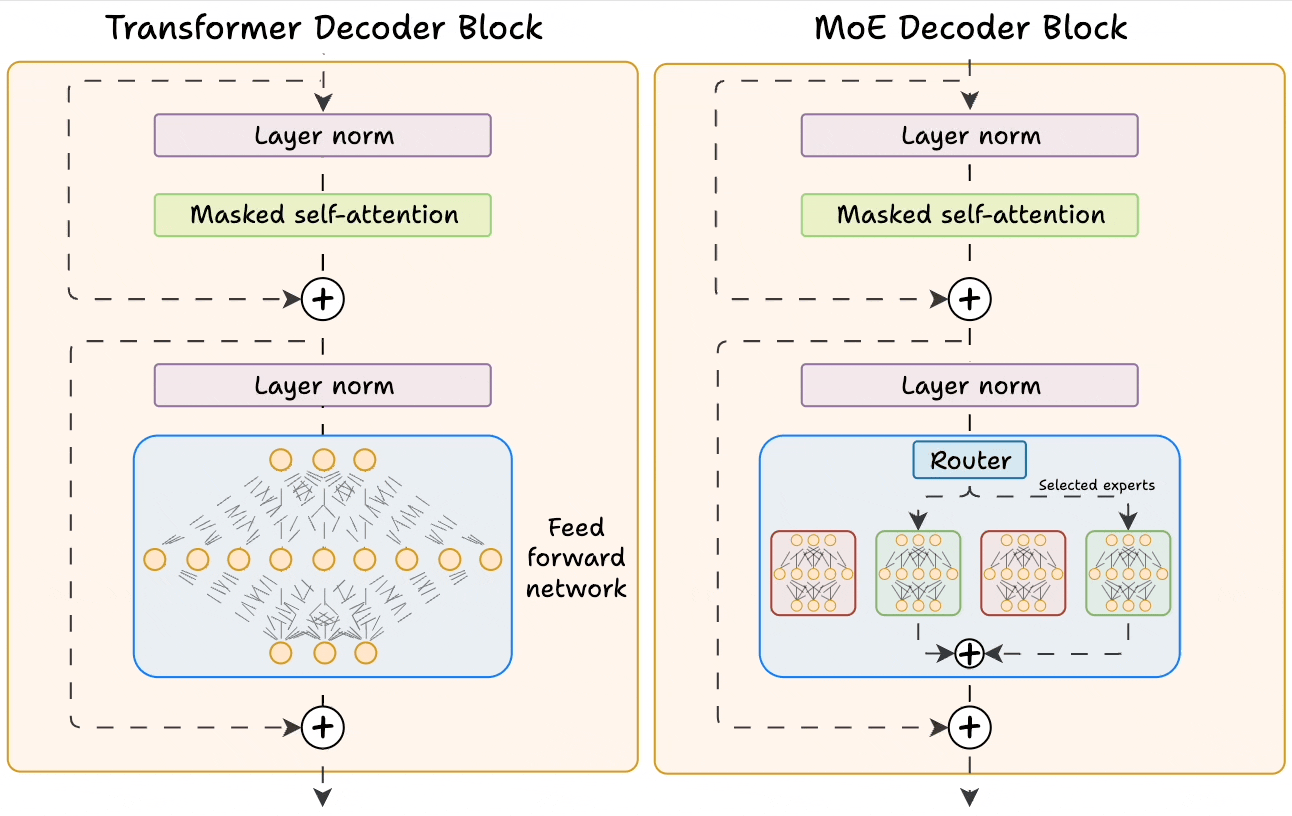
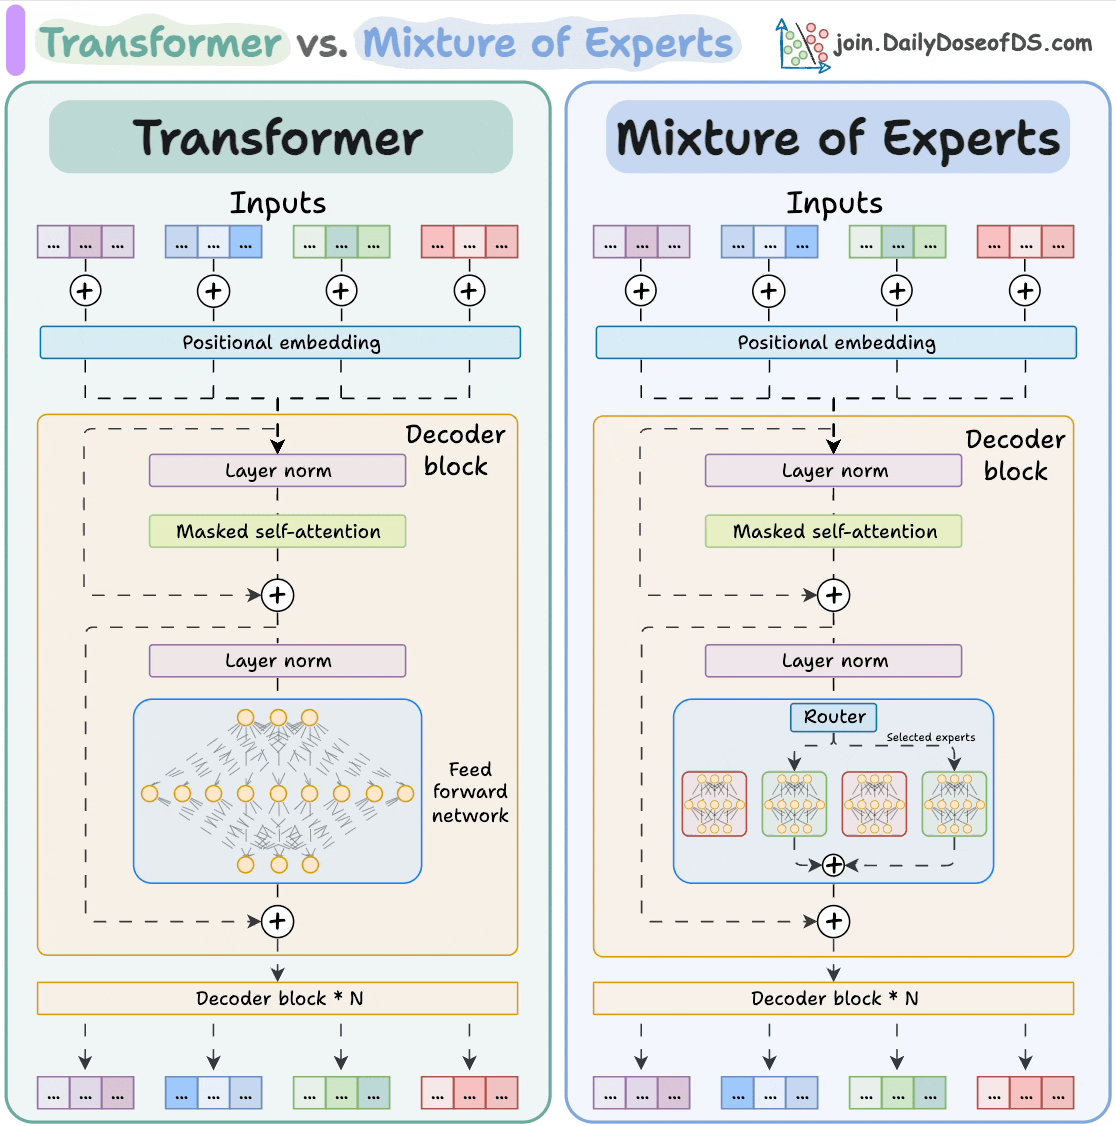

---
### 🔥 Part 3: Building Simple Switch MoE (Top-1 Routing)

#### Step 6: Expert Networks (SwiGLU FFN)

🎯 **What it does:** Each expert is an independent FFN with gated activation

🔧 **Why it matters:** 
- Reuse the SwiGLU pattern from LLaMA (proven to work well)
- Each expert has identical architecture but learns different patterns
- Total params = `n_experts × FFN_params`

💡 **Key insight:** Experts are identical in structure, different in what they learn

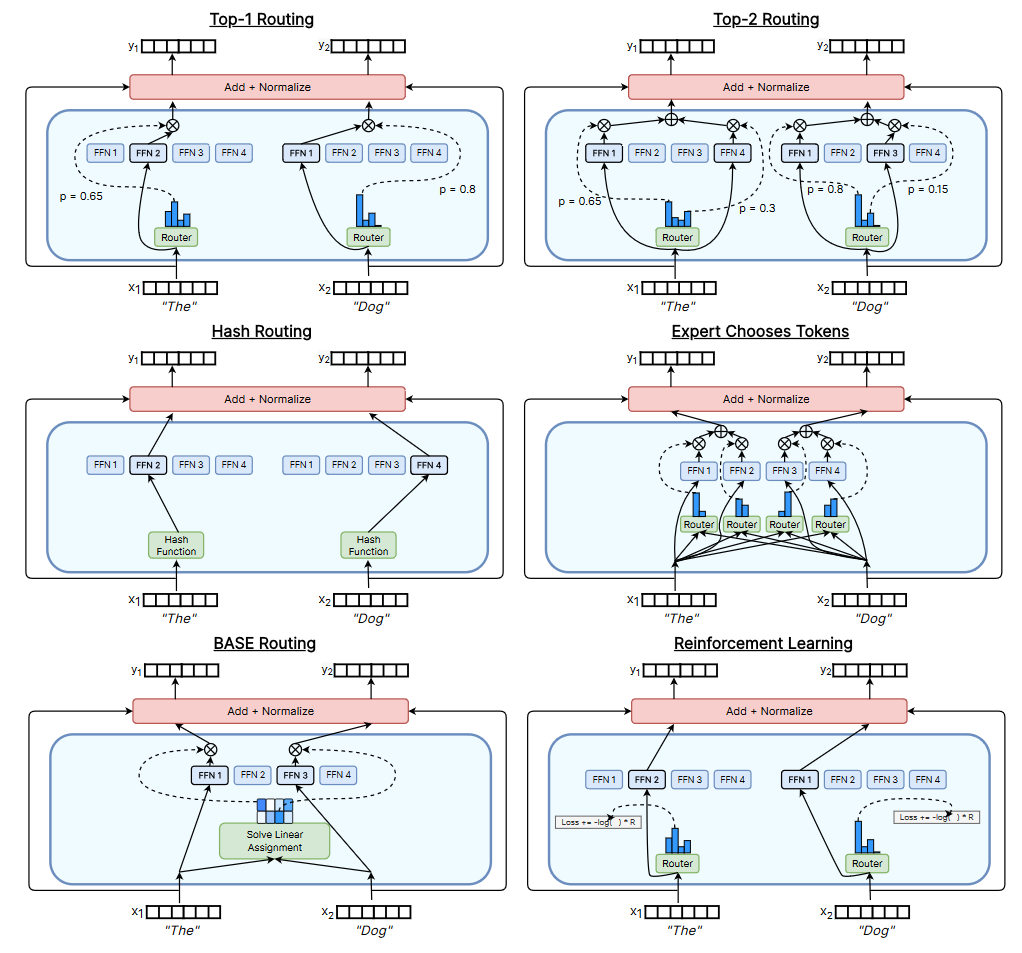

In [24]:
class SwiGLUExpert(nn.Module):
    """Single expert using SwiGLU activation (from LLaMA)"""
    
    def __init__(self, config):
        super().__init__()
        # SwiGLU uses 2/3 rule: multiply by 2/3 then split
        hidden_dim = int(2 * config.d_ff / 3)
        # Make it multiple of 256 for efficiency
        hidden_dim = 256 * ((hidden_dim + 255) // 256)
        
        self.w1 = nn.Linear(config.d_model, hidden_dim, bias=False)  # Gate
        self.w2 = nn.Linear(hidden_dim, config.d_model, bias=False)  # Down projection
        self.w3 = nn.Linear(config.d_model, hidden_dim, bias=False)  # Up projection
    
    def forward(self, x):
        # SwiGLU: swish(W1·x) ⊙ (W3·x)
        gate = F.silu(self.w1(x))  # SiLU = Swish activation
        up = self.w3(x)
        hidden = gate * up  # Element-wise gating
        output = self.w2(hidden)
        return output

# Test single expert
test_expert = SwiGLUExpert(config)
test_input = torch.randn(2, 10, config.d_model)  # (batch, seq, d_model)
test_output = test_expert(test_input)

print(f"✓ Single Expert Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Expert parameters: {sum(p.numel() for p in test_expert.parameters()):,}")

✓ Single Expert Test:
  Input shape: torch.Size([2, 10, 256])
  Output shape: torch.Size([2, 10, 256])
  Expert parameters: 589,824


#### Step 7: Router Network (Learned Gating)

🎯 **What it does:** Learns to assign each token to the best expert(s)

🔧 **Why it matters:** 
- Simple linear layer: `scores = W_router · x`
- Softmax converts to probabilities
- Argmax (Top-1) or TopK (Top-2) selects experts

💡 **Key insight:** The router is what makes experts specialize through gradient flow

In [25]:
class Router(nn.Module):
    """Learned router that assigns tokens to experts"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Simple linear layer for routing
        self.gate = nn.Linear(config.d_model, config.n_experts, bias=False)
        
        # For noisy gating (training only)
        self.noise_std = 0.1
    
    def forward(self, x, training=True):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            expert_indices: (batch, seq_len, top_k) — which experts to use
            expert_weights: (batch, seq_len, top_k) — how much to weight each
            router_logits: (batch, seq_len, n_experts) — for aux loss
        """
        batch, seq_len, d_model = x.shape
        
        # Flatten for routing
        x_flat = x.view(-1, d_model)  # (batch * seq_len, d_model)
        
        # Compute router logits
        router_logits = self.gate(x_flat)  # (batch * seq_len, n_experts)
        
        # Add noise during training for exploration
        if training and self.noise_std > 0:
            noise = torch.randn_like(router_logits) * self.noise_std
            router_logits = router_logits + noise
        
        # Convert to probabilities
        router_probs = F.softmax(router_logits, dim=-1)  # (batch * seq_len, n_experts)
        
        # Select top-k experts
        top_k = self.config.top_k
        expert_weights, expert_indices = torch.topk(router_probs, top_k, dim=-1)
        # expert_weights: (batch * seq_len, top_k)
        # expert_indices: (batch * seq_len, top_k)
        
        # Normalize weights to sum to 1 (within top-k)
        expert_weights = expert_weights / expert_weights.sum(dim=-1, keepdim=True)
        
        # Reshape back
        expert_indices = expert_indices.view(batch, seq_len, top_k)
        expert_weights = expert_weights.view(batch, seq_len, top_k)
        router_logits = router_logits.view(batch, seq_len, self.config.n_experts)
        
        return expert_indices, expert_weights, router_logits

# Test router
test_router = Router(config)
test_input = torch.randn(2, 10, config.d_model)  # (batch=2, seq=10, d_model)

expert_indices, expert_weights, router_logits = test_router(test_input, training=False)

print(f"✓ Router Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Expert indices shape: {expert_indices.shape}")
print(f"  Expert weights shape: {expert_weights.shape}")
print(f"  Router logits shape: {router_logits.shape}")
print(f"\n  Sample routing for first token:")
print(f"    Selected experts: {expert_indices[0, 0].tolist()}")
print(f"    Expert weights: {expert_weights[0, 0].tolist()}")
print(f"    Sum of weights: {expert_weights[0, 0].sum().item():.4f}")

✓ Router Test:
  Input shape: torch.Size([2, 10, 256])
  Expert indices shape: torch.Size([2, 10, 1])
  Expert weights shape: torch.Size([2, 10, 1])
  Router logits shape: torch.Size([2, 10, 4])

  Sample routing for first token:
    Selected experts: [0]
    Expert weights: [1.0]
    Sum of weights: 1.0000


#### Step 8: Auxiliary Load Balancing Loss

🎯 **What it does:** Penalizes uneven expert usage to prevent collapse

🔧 **Why it matters:**
- Without this, router sends all tokens to one "favorite" expert
- Other experts become useless (wasted capacity)
- Auxiliary loss encourages uniform distribution

💡 **Key insight:** Load balancing is critical for MoE success

**Formula:**
$$
L_{\text{aux}} = \alpha \cdot n_{\text{experts}} \cdot \sum_{i=1}^{n_{\text{experts}}} f_i \cdot P_i
$$

Where:
- $f_i$ = fraction of tokens routed to expert $i$
- $P_i$ = average router probability for expert $i$
- $\alpha$ = auxiliary loss weight (typically 0.01)

**Intuition:** If expert $i$ gets many tokens ($f_i$ high) AND has high routing confidence ($P_i$ high), the loss increases → router learns to spread load

### Visual: Load Balancing Problem

![Load Balancing](https://miro.medium.com/v2/resize:fit:1400/1*8Zc8qZ8Z8Z8Z8Z8Z8Z8Z8Z.png)
*Without load balancing, some experts get overloaded while others remain underutilized*

In [26]:
def compute_auxiliary_loss(router_logits, expert_indices, config):
    """
    Compute load balancing auxiliary loss
    
    Args:
        router_logits: (batch, seq_len, n_experts)
        expert_indices: (batch, seq_len, top_k)
        config: MoEConfig
    Returns:
        aux_loss: scalar
    """
    batch, seq_len, n_experts = router_logits.shape
    top_k = expert_indices.shape[-1]
    
    # Convert logits to probabilities
    router_probs = F.softmax(router_logits, dim=-1)  # (batch, seq_len, n_experts)
    
    # Compute P_i: average router probability for each expert
    P = router_probs.mean(dim=[0, 1])  # (n_experts,)
    
    # Compute f_i: fraction of tokens routed to each expert
    # Create one-hot encoding of expert assignments
    expert_mask = torch.zeros(batch, seq_len, n_experts, device=router_logits.device)
    expert_mask.scatter_(2, expert_indices, 1.0)  # Set selected experts to 1
    
    # Average across tokens to get fraction
    f = expert_mask.sum(dim=[0, 1]) / (batch * seq_len * top_k)  # (n_experts,)
    
    # Auxiliary loss: encourages f_i and P_i to be balanced
    aux_loss = n_experts * (f * P).sum()
    
    return aux_loss, P, f

# Test auxiliary loss
test_aux_loss, test_P, test_f = compute_auxiliary_loss(router_logits, expert_indices, config)

print(f"✓ Auxiliary Loss Test:")
print(f"  Loss value: {test_aux_loss.item():.4f}")
print(f"  P (router probabilities): {test_P.detach().numpy()}")
print(f"  f (routing fractions): {test_f.detach().numpy()}")
print(f"  Ideal balance: {1.0/config.n_experts:.3f} per expert")

✓ Auxiliary Loss Test:
  Loss value: 1.0325
  P (router probabilities): [0.26816696 0.2528696  0.26493007 0.21403334]
  f (routing fractions): [0.4  0.25 0.25 0.1 ]
  Ideal balance: 0.250 per expert


#### Step 9: Complete MoE Layer (Switch Architecture)

🎯 **What it does:** Combines router + experts into a single module

🔧 **Why it matters:** Drop-in replacement for standard FFN in Transformer

💡 **Key insight:** Same interface as FFN, but sparse internally

In [27]:
class MoELayer(nn.Module):
    """Mixture of Experts layer with routing"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Create multiple experts
        self.experts = nn.ModuleList([
            SwiGLUExpert(config) for _ in range(config.n_experts)
        ])
        
        # Router
        self.router = Router(config)
    
    def forward(self, x, training=True):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            output: (batch, seq_len, d_model)
            aux_loss: scalar (for training)
            routing_info: dict with expert assignments
        """
        batch, seq_len, d_model = x.shape
        
        # Get routing decisions
        expert_indices, expert_weights, router_logits = self.router(x, training=training)
        # expert_indices: (batch, seq_len, top_k)
        # expert_weights: (batch, seq_len, top_k)
        
        # Compute auxiliary loss
        aux_loss, P, f = compute_auxiliary_loss(router_logits, expert_indices, self.config)
        
        # Initialize output
        output = torch.zeros_like(x)
        
        # Process each expert
        for expert_idx in range(self.config.n_experts):
            # Find tokens routed to this expert
            expert_mask = (expert_indices == expert_idx)  # (batch, seq_len, top_k)
            
            if expert_mask.any():
                # Get expert output for ALL tokens (inefficient but simple for now)
                expert_output = self.experts[expert_idx](x)  # (batch, seq_len, d_model)
                
                # Weight by routing weights
                for k in range(self.config.top_k):
                    mask_k = expert_mask[:, :, k]  # (batch, seq_len)
                    weights_k = expert_weights[:, :, k]  # (batch, seq_len)
                    
                    # Apply weighted contribution
                    contribution = expert_output * weights_k.unsqueeze(-1) * mask_k.unsqueeze(-1)
                    output = output + contribution
        
        # Routing info for analysis
        routing_info = {
            'expert_indices': expert_indices,
            'expert_weights': expert_weights,
            'router_probs': F.softmax(router_logits, dim=-1),
            'load_balance_P': P,
            'load_balance_f': f
        }
        
        return output, aux_loss, routing_info

# Test MoE layer
test_moe = MoELayer(config)
test_input = torch.randn(2, 10, config.d_model)
test_output, test_aux_loss, test_routing_info = test_moe(test_input, training=True)

print(f"✓ MoE Layer Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Auxiliary loss: {test_aux_loss.item():.4f}")
print(f"  Total parameters: {sum(p.numel() for p in test_moe.parameters()):,}")
print(f"\n  Expert usage (fraction):")
for i, frac in enumerate(test_routing_info['load_balance_f']):
    print(f"    Expert {i}: {frac.item():.3f}")

✓ MoE Layer Test:
  Input shape: torch.Size([2, 10, 256])
  Output shape: torch.Size([2, 10, 256])
  Auxiliary loss: 1.0302
  Total parameters: 2,360,320

  Expert usage (fraction):
    Expert 0: 0.400
    Expert 1: 0.250
    Expert 2: 0.100
    Expert 3: 0.250


#### 🔬 Deep Dive: Noisy Top-K Gating

**The Problem:** Without noise, the router quickly converges to deterministic routing
- Token type A → always Expert 1
- Token type B → always Expert 2
- Early training biases become permanent

**The Solution:** Add Gumbel noise during training

$$
\text{logits}_{\text{noisy}} = \text{logits} + \mathcal{N}(0, \sigma^2)
$$

**Why it works:**
- Encourages **exploration** of different expert assignments
- Prevents **expert collapse** (all tokens to one expert)
- Creates **diversity** in expert specialization
- Removed at inference (deterministic routing)

**Typical values:** $\sigma = 0.1$ (10% noise)

**Training vs Inference:**
```python
# Training: router(x, training=True) → adds noise
# Inference: router(x, training=False) → no noise
```

This is already implemented in our `Router.forward()` method above!

---
### 🔥 Part 4: Upgrading to Mixtral (Top-2 Routing)

#### The Mixtral Innovation

**Switch Transformer (Google, 2021):**
- Top-1 routing: Each token goes to ONE expert
- Simpler, more sparse (1 of N experts active)
- Requires expert capacity + token dropping

**Mixtral 8×7B (Mistral AI, 2023):**
- Top-2 routing: Each token goes to TWO experts
- More stable, better quality
- No token dropping needed
- Current SOTA for open-source MoE

**The change needed:** Just set `top_k=2` in config! Our router already supports it.

### Visual: Mixtral Performance

![Mixtral Benchmarks](https://mistral.ai/images/news/mixtral-of-experts/overview.png)
*Mixtral 8x7B achieves competitive performance while maintaining efficiency (Image credit: Mistral AI)*

In [28]:
# Upgrade to Mixtral-style Top-2 routing
config_mixtral = MoEConfig(
    top_k=2,  # Use 2 experts per token
    moe_architecture="mixtral",
    n_experts=4,
    d_model=256,
    n_layers=4,
    vocab_size=tokenizer.vocab_size
)

print(f"✓ Mixtral Configuration:")
print(f"  Architecture: {config_mixtral.moe_architecture}")
print(f"  Top-K: {config_mixtral.top_k}")
print(f"  Experts: {config_mixtral.n_experts}")
print(f"  Active per token: {config_mixtral.top_k} experts")
print(f"  Sparsity: {config_mixtral.top_k}/{config_mixtral.n_experts} = {config_mixtral.top_k/config_mixtral.n_experts:.1%}")

# Test Mixtral-style MoE
test_moe_mixtral = MoELayer(config_mixtral)
test_input = torch.randn(2, 10, config_mixtral.d_model)
test_output, test_aux_loss, test_routing_info = test_moe_mixtral(test_input, training=True)

print(f"\n✓ Mixtral MoE Test:")
print(f"  Output shape: {test_output.shape}")
print(f"  Experts per token: {test_routing_info['expert_indices'].shape[-1]}")
print(f"\n  Sample routing (first token):")
print(f"    Experts: {test_routing_info['expert_indices'][0, 0].tolist()}")
print(f"    Weights: {test_routing_info['expert_weights'][0, 0].tolist()}")
print(f"    Weight sum: {test_routing_info['expert_weights'][0, 0].sum().item():.4f}")

✓ Mixtral Configuration:
  Architecture: mixtral
  Top-K: 2
  Experts: 4
  Active per token: 2 experts
  Sparsity: 2/4 = 50.0%

✓ Mixtral MoE Test:
  Output shape: torch.Size([2, 10, 256])
  Experts per token: 2

  Sample routing (first token):
    Experts: [1, 2]
    Weights: [0.8425127863883972, 0.15748725831508636]
    Weight sum: 1.0000


#### 🔬 Deep Dive: Switch vs Mixtral Architecture Comparison

| Aspect | Switch Transformer | Mixtral 8×7B | Winner |
|--------|-------------------|--------------|--------|
| **Routing** | Top-1 (one expert) | Top-2 (two experts) | ⚖️ Trade-off |
| **Sparsity** | 1/N (12.5% for N=8) | 2/N (25% for N=8) | 🏆 Switch (more sparse) |
| **Compute per Token** | 1× expert size | 2× expert size | 🏆 Switch (faster) |
| **Training Stability** | Less stable | More stable | 🏆 Mixtral |
| **Quality** | Good | Better | 🏆 Mixtral |
| **Token Dropping** | Required (capacity) | Not needed | 🏆 Mixtral (simpler) |
| **Expert Collapse Risk** | Higher | Lower | 🏆 Mixtral |
| **Load Balancing** | Critical | Still important | 🏆 Mixtral (more forgiving) |
| **Inference Latency** | Lower | Slightly higher | 🏆 Switch |
| **Memory Bandwidth** | Less | More | 🏆 Switch |
| **Real-world Success** | T5 variants | Mixtral 8×7B | 🏆 Mixtral (open-source!) |

**When to use Switch (Top-1):**
- Maximum efficiency/sparsity needed
- Large number of experts (N > 64)
- Strict latency requirements

**When to use Mixtral (Top-2):**
- Quality is priority
- Training stability matters
- Moderate expert count (N = 4-16)
- Open-source deployment

**Bottom line:** Mixtral's Top-2 routing is the current best practice for most use cases

### Visual: Top-K Routing Comparison

![Top-K Routing](https://production-media.paperswithcode.com/methods/Screen_Shot_2022-06-23_at_4.36.26_PM_Y0q7V5j.png)
*Top-1 (Switch) vs Top-2 (Mixtral) routing strategies (Image credit: Papers with Code)*

#### 🔬 Deep Dive: Expert Capacity and Token Dropping

**The Problem:** Uneven routing can cause memory overflow

Imagine we have:
- 4 experts
- 1000 tokens
- Perfect balance → 250 tokens per expert
- But router sends 600 tokens to Expert 1!

**Solution: Expert Capacity**

$$
\text{capacity} = \left\lceil \frac{\text{tokens} \times \text{top\_k}}{n_{\text{experts}}} \times \text{capacity\_factor} \right\rceil
$$

**Parameters:**
- `capacity_factor = 1.0` → Only perfectly balanced load allowed
- `capacity_factor = 1.25` → Allow 25% overflow (typical)
- `capacity_factor = 1.5` → Allow 50% overflow

**Example:**
```
tokens = 1000, top_k = 1, n_experts = 4, capacity_factor = 1.25
capacity = ceil((1000 × 1) / 4 × 1.25) = ceil(312.5) = 313
```

**Token Dropping:**
- If expert receives > capacity tokens, drop the overflow
- Dropped tokens bypass the expert (identity mapping)
- Loss signal encourages router to balance better

**Switch vs Mixtral:**
- **Switch (Top-1):** Capacity is critical (high imbalance)
- **Mixtral (Top-2):** Less critical (tokens have backup expert)

**For our educational implementation:** We skip capacity enforcement for simplicity. In production, it's essential for distributed training!

---
### 🔥 Part 5: Complete MoE Transformer Model

#### Step 10: Import LLaMA Components

We'll reuse the battle-tested components from LLaMA:
- **RoPE:** Rotary Position Embeddings
- **RMSNorm:** Root Mean Square Normalization
- **GQA:** Grouped Query Attention

This lets us focus on MoE-specific innovations!

In [32]:
# RMSNorm (from LLaMA)
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    
    def forward(self, x):
        # RMS = sqrt(mean(x^2))
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        x_normed = x / rms
        return self.weight * x_normed

# RoPE (from LLaMA)
class RoPE(nn.Module):
    def __init__(self, dim, max_seq_len=2048, base=10000):
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base
        
        # Precompute frequencies
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
        
        # Precompute cos/sin for max_seq_len
        t = torch.arange(max_seq_len, dtype=torch.float32)
        freqs = torch.outer(t, inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer('cos_cached', emb.cos())
        self.register_buffer('sin_cached', emb.sin())
    
    def forward(self, x):
        # x shape: (batch, seq_len, n_heads, head_dim) or (batch, seq_len, head_dim)
        seq_len = x.shape[1]
        cos = self.cos_cached[:seq_len, :self.dim]
        sin = self.sin_cached[:seq_len, :self.dim]
        
        # Reshape for broadcasting: (seq_len, dim) -> (1, seq_len, 1, dim)
        if x.dim() == 4:  # (batch, seq_len, n_heads, head_dim)
            cos = cos.unsqueeze(0).unsqueeze(2)
            sin = sin.unsqueeze(0).unsqueeze(2)
        else:  # (batch, seq_len, dim)
            cos = cos.unsqueeze(0)
            sin = sin.unsqueeze(0)
        
        # Apply rotation
        x1, x2 = x[..., :self.dim//2], x[..., self.dim//2:]
        rotated = torch.cat([
            x1 * cos[..., :self.dim//2] - x2 * sin[..., :self.dim//2],
            x1 * sin[..., :self.dim//2] + x2 * cos[..., :self.dim//2]
        ], dim=-1)
        return rotated

# Grouped Query Attention (from LLaMA)
class GroupedQueryAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.n_kv_heads = config.n_kv_heads
        self.head_dim = config.head_dim
        self.n_rep = self.n_heads // self.n_kv_heads
        
        self.wq = nn.Linear(config.d_model, config.n_heads * config.head_dim, bias=False)
        self.wk = nn.Linear(config.d_model, config.n_kv_heads * config.head_dim, bias=False)
        self.wv = nn.Linear(config.d_model, config.n_kv_heads * config.head_dim, bias=False)
        self.wo = nn.Linear(config.n_heads * config.head_dim, config.d_model, bias=False)
        
        self.rope = RoPE(config.head_dim, config.max_seq_len)
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, x, mask=None):
        batch, seq_len, _ = x.shape
        
        # Project to Q, K, V
        q = self.wq(x).view(batch, seq_len, self.n_heads, self.head_dim)
        k = self.wk(x).view(batch, seq_len, self.n_kv_heads, self.head_dim)
        v = self.wv(x).view(batch, seq_len, self.n_kv_heads, self.head_dim)
        
        # Apply RoPE
        q = self.rope(q)
        k = self.rope(k)
        
        # Repeat KV heads for GQA
        k = k.repeat_interleave(self.n_rep, dim=2)
        v = v.repeat_interleave(self.n_rep, dim=2)
        
        # Transpose for attention
        q = q.transpose(1, 2)  # (batch, n_heads, seq, head_dim)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        if mask is not None:
            scores = scores + mask
        
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        output = torch.matmul(attn, v)  # (batch, n_heads, seq, head_dim)
        output = output.transpose(1, 2).contiguous()  # (batch, seq, n_heads, head_dim)
        output = output.view(batch, seq_len, -1)  # (batch, seq, d_model)
        
        # Final projection
        output = self.wo(output)
        return output

print("✓ LLaMA components imported successfully!")
print("  RMSNorm, RoPE, GroupedQueryAttention ready")

✓ LLaMA components imported successfully!
  RMSNorm, RoPE, GroupedQueryAttention ready


#### Step 11: MoE Transformer Block

🎯 **What it does:** Complete transformer block with MoE instead of FFN

🔧 **Why it matters:** This is the building block we'll stack into a full model

💡 **Key insight:** Only the FFN is replaced — attention stays dense!

In [33]:
class MoETransformerBlock(nn.Module):
    """Transformer block with MoE replacing the FFN"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Pre-normalization (LLaMA style)
        self.norm1 = RMSNorm(config.d_model)
        self.norm2 = RMSNorm(config.d_model)
        
        # Attention (stays dense!)
        self.attention = GroupedQueryAttention(config)
        
        # MoE layer (replaces standard FFN)
        self.moe = MoELayer(config)
    
    def forward(self, x, mask=None, training=True):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            x: (batch, seq_len, d_model)
            aux_loss: scalar
            routing_info: dict
        """
        # Self-attention with residual (pre-norm)
        x = x + self.attention(self.norm1(x), mask)
        
        # MoE with residual (pre-norm)
        moe_input = self.norm2(x)
        moe_output, aux_loss, routing_info = self.moe(moe_input, training=training)
        x = x + moe_output
        
        return x, aux_loss, routing_info

# Test transformer block
test_block = MoETransformerBlock(config_mixtral)
test_input = torch.randn(2, 10, config_mixtral.d_model)
test_output, test_aux_loss, test_routing_info = test_block(test_input, training=True)

print(f"✓ MoE Transformer Block Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Auxiliary loss: {test_aux_loss.item():.4f}")
print(f"  Block parameters: {sum(p.numel() for p in test_block.parameters()):,}")

✓ MoE Transformer Block Test:
  Input shape: torch.Size([2, 10, 256])
  Output shape: torch.Size([2, 10, 256])
  Auxiliary loss: 1.0053
  Block parameters: 2,557,440


#### Step 12: Complete MoE Transformer Model

Stack multiple blocks into a full language model!

In [34]:
class MoETransformer(nn.Module):
    """Complete MoE Transformer for language modeling"""
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Token embeddings
        self.tok_embeddings = nn.Embedding(config.vocab_size, config.d_model)
        
        # Transformer blocks
        self.layers = nn.ModuleList([
            MoETransformerBlock(config) for _ in range(config.n_layers)
        ])
        
        # Final norm and output
        self.norm = RMSNorm(config.d_model)
        self.output = nn.Linear(config.d_model, config.vocab_size, bias=False)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, idx, targets=None, training=True):
        """
        Args:
            idx: (batch, seq_len) token indices
            targets: (batch, seq_len) target indices (optional)
        Returns:
            logits: (batch, seq_len, vocab_size)
            loss: scalar (if targets provided)
            aux_loss: scalar (sum across layers)
        """
        batch, seq_len = idx.shape
        
        # Embed tokens
        x = self.tok_embeddings(idx)  # (batch, seq_len, d_model)
        
        # Create causal mask
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        mask = mask.to(idx.device)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        
        # Pass through transformer blocks
        total_aux_loss = 0.0
        all_routing_info = []
        
        for layer in self.layers:
            x, aux_loss, routing_info = layer(x, mask=mask, training=training)
            total_aux_loss += aux_loss
            all_routing_info.append(routing_info)
        
        # Final norm and projection
        x = self.norm(x)
        logits = self.output(x)  # (batch, seq_len, vocab_size)
        
        # Calculate loss if targets provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.config.vocab_size),
                targets.view(-1)
            )
        
        return logits, loss, total_aux_loss, all_routing_info

# Create model
model = MoETransformer(config_mixtral).to(device)

print(f"✓ MoE Transformer Model Created!")
print(f"  Architecture: {config_mixtral.moe_architecture}")
print(f"  Layers: {config_mixtral.n_layers}")
print(f"  Experts per layer: {config_mixtral.n_experts}")
print(f"  Top-K: {config_mixtral.top_k}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {device}")

# Test forward pass
test_idx = torch.randint(0, config_mixtral.vocab_size, (2, 20)).to(device)
test_targets = torch.randint(0, config_mixtral.vocab_size, (2, 20)).to(device)

with torch.no_grad():
    logits, loss, aux_loss, routing_info = model(test_idx, test_targets, training=False)

print(f"\n✓ Forward Pass Test:")
print(f"  Input shape: {test_idx.shape}")
print(f"  Logits shape: {logits.shape}")
print(f"  Cross-entropy loss: {loss.item():.4f}")
print(f"  Auxiliary loss: {aux_loss.item():.4f}")
print(f"  Total loss: {(loss + config_mixtral.aux_loss_weight * aux_loss).item():.4f}")

✓ MoE Transformer Model Created!
  Architecture: mixtral
  Layers: 4
  Experts per layer: 4
  Top-K: 2
  Total parameters: 10,251,520
  Device: cpu

✓ Forward Pass Test:
  Input shape: torch.Size([2, 20])
  Logits shape: torch.Size([2, 20, 42])
  Cross-entropy loss: 3.7630
  Auxiliary loss: 4.6837
  Total loss: 3.8098


---
### 🔥 Part 6: Training Loop with Expert Tracking

#### Step 13: Training Setup

In [35]:
# Training hyperparameters
learning_rate = 3e-4
num_epochs = 25
grad_clip = 1.0

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Training history for visualization
history = {
    'train_loss': [],
    'train_ce_loss': [],
    'train_aux_loss': [],
    'val_loss': [],
    'expert_usage': [],  # Track expert activation per epoch
    'expert_by_domain': []  # Track expert specialization by domain
}

print(f"✓ Training Setup Complete:")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")
print(f"  Gradient clipping: {grad_clip}")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: CosineAnnealingLR")

✓ Training Setup Complete:
  Learning rate: 0.0003
  Epochs: 25
  Gradient clipping: 1.0
  Optimizer: AdamW
  Scheduler: CosineAnnealingLR


#### Step 14: Training Loop with Expert Monitoring

💡 **Key insight:** We track which experts activate for which domains!

In [36]:
def train_epoch(model, loader, optimizer, config, epoch):
    """Train for one epoch and track expert usage"""
    model.train()
    total_loss = 0
    total_ce_loss = 0
    total_aux_loss = 0
    
    # Track expert usage by domain
    expert_domain_counts = {}  # {domain: [counts per expert]}
    
    for batch_idx, (x, y, domains) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits, ce_loss, aux_loss, routing_info = model(x, y, training=True)
        
        # Combined loss
        total_loss_batch = ce_loss + config.aux_loss_weight * aux_loss
        
        # Backward pass
        total_loss_batch.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        
        # Track losses
        total_loss += total_loss_batch.item()
        total_ce_loss += ce_loss.item()
        total_aux_loss += aux_loss.item()
        
        # Track expert usage by domain (use last layer)
        last_layer_routing = routing_info[-1]
        expert_indices = last_layer_routing['expert_indices'].cpu()  # (batch, seq, top_k)
        
        for i, domain in enumerate(domains):
            if domain not in expert_domain_counts:
                expert_domain_counts[domain] = [0] * config.n_experts
            
            # Count which experts were used for this domain
            batch_experts = expert_indices[i].flatten()  # All experts for this sequence
            for expert_idx in batch_experts:
                expert_domain_counts[domain][expert_idx.item()] += 1
        
        # Progress
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} | "
                  f"Loss: {total_loss_batch.item():.4f} "
                  f"(CE: {ce_loss.item():.4f}, Aux: {aux_loss.item():.4f})")
    
    # Average losses
    avg_loss = total_loss / len(loader)
    avg_ce_loss = total_ce_loss / len(loader)
    avg_aux_loss = total_aux_loss / len(loader)
    
    return avg_loss, avg_ce_loss, avg_aux_loss, expert_domain_counts

def validate(model, loader, config):
    """Validation pass"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            logits, ce_loss, aux_loss, _ = model(x, y, training=False)
            total_loss += (ce_loss + config.aux_loss_weight * aux_loss).item()
    
    return total_loss / len(loader)

print("✓ Training functions defined")
print("  Ready to train with expert tracking!")

✓ Training functions defined
  Ready to train with expert tracking!


#### Step 15: Run Training!

In [37]:
print("🚀 Starting MoE Training...\n")
print(f"Training for {num_epochs} epochs on {len(train_loader)} batches per epoch")
print(f"Validation on {len(val_loader)} batches\n")
print("="*70)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 70)
    
    # Train
    train_loss, train_ce, train_aux, expert_domain = train_epoch(
        model, train_loader, optimizer, config_mixtral, epoch
    )
    
    # Validate
    val_loss = validate(model, val_loader, config_mixtral)
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_ce_loss'].append(train_ce)
    history['train_aux_loss'].append(train_aux)
    history['val_loss'].append(val_loss)
    history['expert_by_domain'].append(expert_domain)
    
    # Calculate overall expert usage
    total_expert_counts = [0] * config_mixtral.n_experts
    for domain, counts in expert_domain.items():
        for i, count in enumerate(counts):
            total_expert_counts[i] += count
    history['expert_usage'].append(total_expert_counts)
    
    # Print summary
    print(f"\n  Train Loss: {train_loss:.4f} (CE: {train_ce:.4f}, Aux: {train_aux:.4f})")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"\n  Expert Usage:")
    total = sum(total_expert_counts)
    for i, count in enumerate(total_expert_counts):
        pct = 100 * count / total if total > 0 else 0
        print(f"    Expert {i}: {pct:.1f}%")

print("\n" + "="*70)
print("✅ Training Complete!")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss: {history['val_loss'][-1]:.4f}")

🚀 Starting MoE Training...

Training for 25 epochs on 57 batches per epoch
Validation on 7 batches


Epoch 1/25
----------------------------------------------------------------------
  Batch 0/57 | Loss: 3.8469 (CE: 3.8008, Aux: 4.6096)

  Train Loss: 1.5756 (CE: 1.5329, Aux: 4.2662)
  Val Loss: 0.4315
  LR: 0.000299

  Expert Usage:
    Expert 0: 23.9%
    Expert 1: 21.2%
    Expert 2: 27.4%
    Expert 3: 27.4%

Epoch 2/25
----------------------------------------------------------------------
  Batch 0/57 | Loss: 0.5033 (CE: 0.4625, Aux: 4.0819)

  Train Loss: 0.1220 (CE: 0.0817, Aux: 4.0294)
  Val Loss: 0.0512
  LR: 0.000295

  Expert Usage:
    Expert 0: 22.5%
    Expert 1: 24.2%
    Expert 2: 25.2%
    Expert 3: 28.2%

Epoch 3/25
----------------------------------------------------------------------
  Batch 0/57 | Loss: 0.0523 (CE: 0.0119, Aux: 4.0410)

  Train Loss: 0.0494 (CE: 0.0093, Aux: 4.0130)
  Val Loss: 0.0450
  LR: 0.000289

  Expert Usage:
    Expert 0: 24.7%
    Expert 1

#### Step 16: Save Checkpoint

In [38]:
# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': config_mixtral,
    'history': history,
    'epoch': num_epochs,
    'tokenizer': {'char_to_idx': tokenizer.char_to_idx, 'idx_to_char': tokenizer.idx_to_char}
}

torch.save(checkpoint, 'moe_checkpoint.pt')
print("✓ Model checkpoint saved to moe_checkpoint.pt")

✓ Model checkpoint saved to moe_checkpoint.pt


---
### 🔥 Part 7: Animated Expert Analysis & Visualization

#### Step 17: Create Animated Expert Evolution Visualization

🎯 **What it does:** Animate how expert specialization evolves during training

🔧 **Why it matters:** See the "aha!" moment when experts learn different domains

💡 **Key insight:** Expert specialization emerges gradually through training

### Visual: Expert Specialization

![Expert Specialization](https://miro.medium.com/v2/resize:fit:1400/1*xqZ6qZHh9oDWYGPqZqJXKg.png)
*During training, experts naturally specialize across different domains and tasks (Image credit: Medium)*

In [39]:
# Prepare data for animation
def prepare_animation_data(history, config):
    """Convert history to format suitable for animation"""
    n_epochs = len(history['expert_by_domain'])
    domains = sorted(list(history['expert_by_domain'][0].keys()))
    n_experts = config.n_experts
    
    # Create matrices for each epoch
    epoch_matrices = []
    for epoch_data in history['expert_by_domain']:
        # Create domain x expert matrix
        matrix = np.zeros((len(domains), n_experts))
        for i, domain in enumerate(domains):
            if domain in epoch_data:
                counts = np.array(epoch_data[domain])
                # Normalize to percentages
                total = counts.sum()
                if total > 0:
                    matrix[i, :] = 100 * counts / total
        epoch_matrices.append(matrix)
    
    return epoch_matrices, domains

epoch_matrices, domains = prepare_animation_data(history, config_mixtral)
print(f"✓ Animation data prepared:")
print(f"  Epochs: {len(epoch_matrices)}")
print(f"  Domains: {domains}")
print(f"  Experts: {config_mixtral.n_experts}")

✓ Animation data prepared:
  Epochs: 25
  Domains: ['News', 'Review']
  Experts: 4


✓ Creating animation... (this may take a moment)


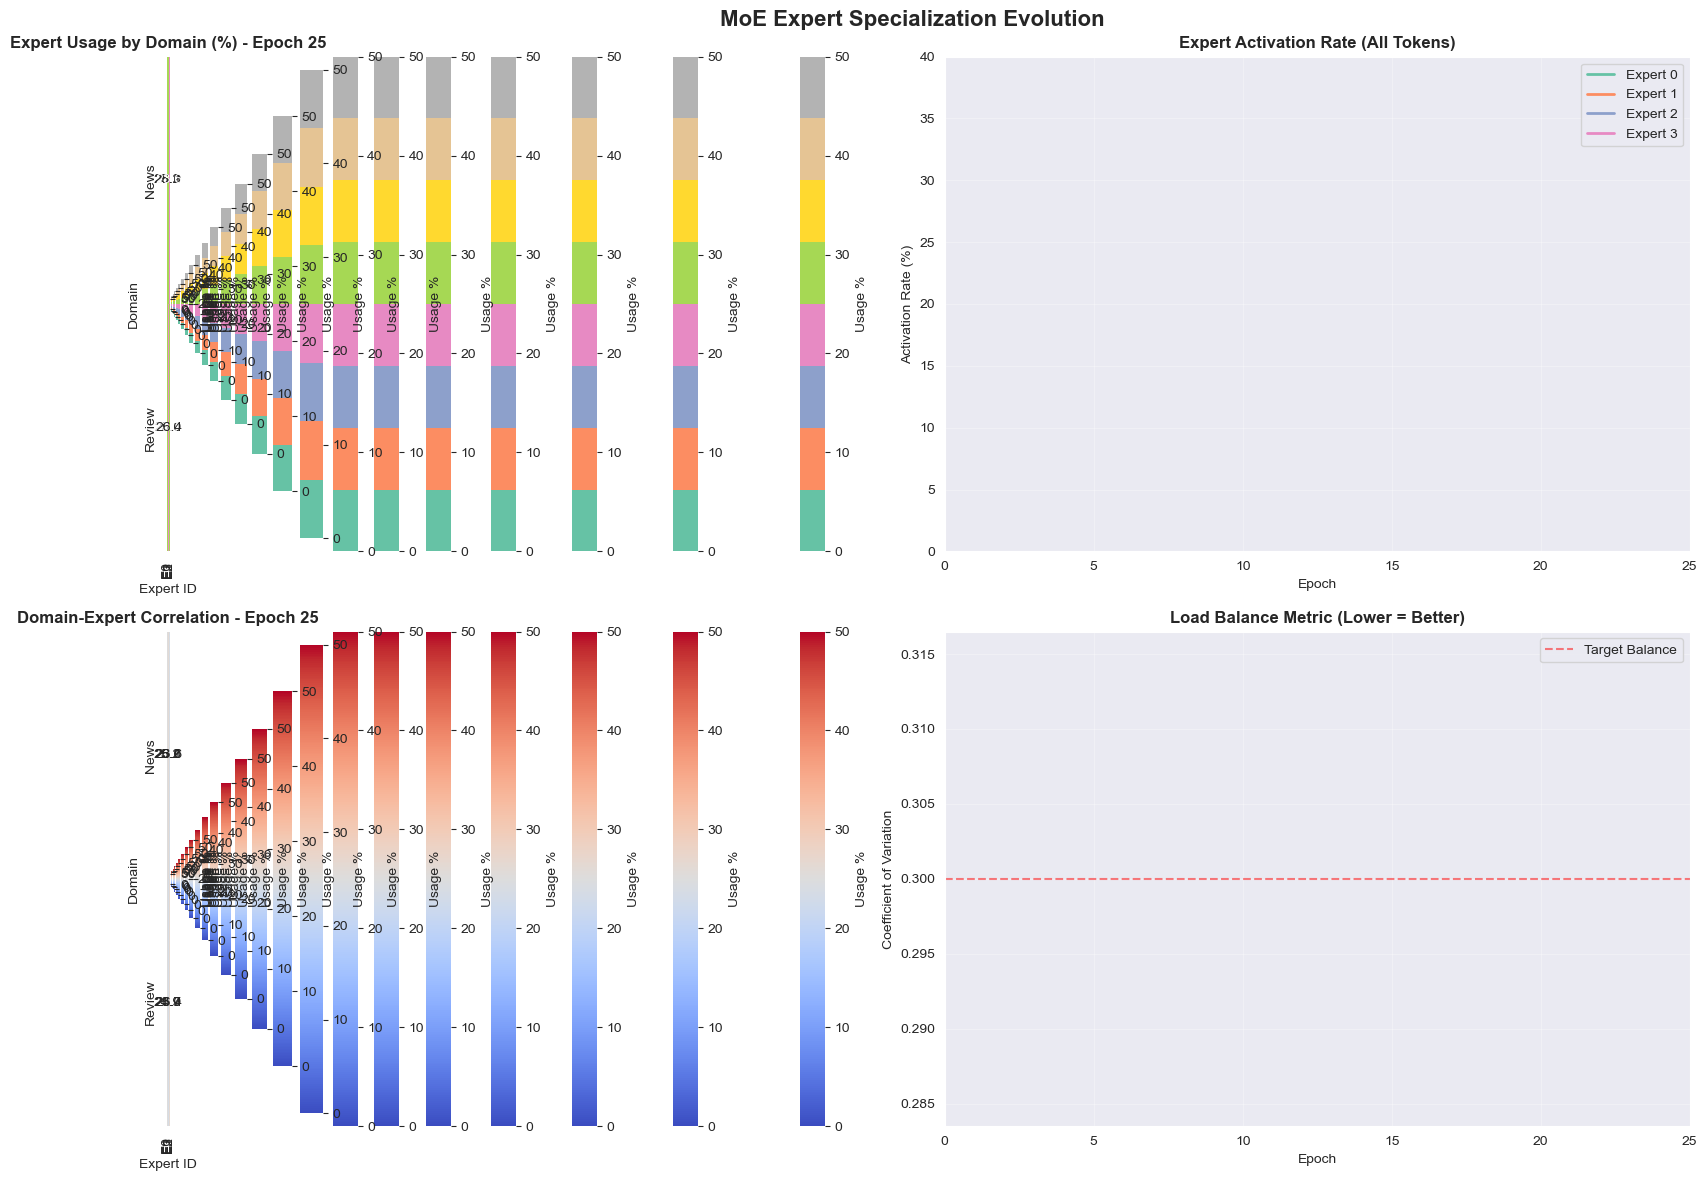

In [40]:
# Create 2x2 animated visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MoE Expert Specialization Evolution', fontsize=16, fontweight='bold')

# Subplot 1: Expert Utilization Heatmap
ax1 = axes[0, 0]
ax1.set_title('Expert Usage by Domain (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Expert ID')
ax1.set_ylabel('Domain')

# Subplot 2: Expert Activation Rate Over Time
ax2 = axes[0, 1]
ax2.set_title('Expert Activation Rate (All Tokens)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Activation Rate (%)')
ax2.set_xlim(0, num_epochs)
ax2.set_ylim(0, 40)
ax2.grid(True, alpha=0.3)

# Subplot 3: Domain-Expert Correlation
ax3 = axes[1, 0]
ax3.set_title('Domain-Expert Correlation Matrix', fontsize=12, fontweight='bold')
ax3.set_xlabel('Expert ID')
ax3.set_ylabel('Domain')

# Subplot 4: Load Balance Metric (Coefficient of Variation)
ax4 = axes[1, 1]
ax4.set_title('Load Balance Metric (Lower = Better)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Coefficient of Variation')
ax4.set_xlim(0, num_epochs)
ax4.axhline(y=0.3, color='r', linestyle='--', label='Target Balance', alpha=0.5)
ax4.grid(True, alpha=0.3)
ax4.legend()

# Initialize empty plots
expert_labels = [f'E{i}' for i in range(config_mixtral.n_experts)]
expert_colors = sns.color_palette('Set2', config_mixtral.n_experts)

# Lines for subplot 2
lines = []
for i in range(config_mixtral.n_experts):
    line, = ax2.plot([], [], label=f'Expert {i}', color=expert_colors[i], linewidth=2)
    lines.append(line)
ax2.legend(loc='upper right')

# Line for subplot 4
cv_line, = ax4.plot([], [], color='cyan', linewidth=2)

def init():
    """Initialize animation"""
    for line in lines:
        line.set_data([], [])
    cv_line.set_data([], [])
    return lines + [cv_line]

def animate(frame):
    """Update animation for frame (epoch)"""
    epoch = frame
    
    # Clear previous plots
    ax1.clear()
    ax3.clear()
    
    # Subplot 1: Heatmap at current epoch
    sns.heatmap(epoch_matrices[epoch], annot=True, fmt='.1f', cmap='Set2',
                xticklabels=expert_labels, yticklabels=domains,
                cbar_kws={'label': 'Usage %'}, ax=ax1, vmin=0, vmax=50)
    ax1.set_title(f'Expert Usage by Domain (%) - Epoch {epoch+1}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Expert ID')
    ax1.set_ylabel('Domain')
    
    # Subplot 2: Expert activation over time (cumulative)
    for i in range(config_mixtral.n_experts):
        expert_rates = []
        for e in range(epoch + 1):
            usage = history['expert_usage'][e]
            total = sum(usage)
            rate = 100 * usage[i] / total if total > 0 else 0
            expert_rates.append(rate)
        lines[i].set_data(range(epoch + 1), expert_rates)
    
    # Subplot 3: Correlation matrix at current epoch
    sns.heatmap(epoch_matrices[epoch], annot=True, fmt='.1f', cmap='coolwarm',
                xticklabels=expert_labels, yticklabels=domains, center=25,
                cbar_kws={'label': 'Usage %'}, ax=ax3, vmin=0, vmax=50)
    ax3.set_title(f'Domain-Expert Correlation - Epoch {epoch+1}', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Expert ID')
    ax3.set_ylabel('Domain')
    
    # Subplot 4: Load balance metric (CV)
    cv_values = []
    for e in range(epoch + 1):
        usage = np.array(history['expert_usage'][e])
        if usage.sum() > 0:
            cv = usage.std() / usage.mean()  # Coefficient of variation
        else:
            cv = 0
        cv_values.append(cv)
    cv_line.set_data(range(epoch + 1), cv_values)
    
    plt.tight_layout()
    return lines + [cv_line]

# Create animation
anim = FuncAnimation(fig, animate, init_func=init, frames=num_epochs, 
                    interval=500, blit=False, repeat=True)

# Display animation
print("✓ Creating animation... (this may take a moment)")
HTML(anim.to_jshtml())

#### Step 18: Final Expert Specialization Analysis

Let's analyze which experts specialized in which domains!

In [41]:
# Analyze final expert specialization
print("🔍 Expert Specialization Analysis\n")
print("="*70)

final_domain_counts = history['expert_by_domain'][-1]

# For each expert, find top domains
for expert_idx in range(config_mixtral.n_experts):
    print(f"\n🧠 Expert {expert_idx}:")
    print("-" * 50)
    
    domain_prefs = []
    for domain in domains:
        if domain in final_domain_counts:
            counts = final_domain_counts[domain]
            total = sum(counts)
            if total > 0:
                pct = 100 * counts[expert_idx] / total
                domain_prefs.append((domain, pct, counts[expert_idx]))
    
    # Sort by percentage
    domain_prefs.sort(key=lambda x: x[1], reverse=True)
    
    # Show top domains
    for domain, pct, count in domain_prefs[:3]:
        print(f"  {domain:20s}: {pct:5.1f}% ({count:,} activations)")
    
    # Specialization score (entropy-based)
    probs = np.array([p[1] for p in domain_prefs]) / 100
    probs = probs[probs > 0]  # Remove zeros
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    max_entropy = np.log(len(domains))
    specialization = 1 - (entropy / max_entropy)  # 1 = fully specialized, 0 = uniform
    print(f"  Specialization Score: {specialization:.3f} (1.0 = highly specialized)")

print("\n" + "="*70)
print("✅ Analysis Complete!")

🔍 Expert Specialization Analysis


🧠 Expert 0:
--------------------------------------------------
  News                :  25.2% (57,577 activations)
  Review              :  24.9% (57,790 activations)
  Specialization Score: -0.000 (1.0 = highly specialized)

🧠 Expert 1:
--------------------------------------------------
  News                :  25.1% (57,320 activations)
  Review              :  25.0% (58,177 activations)
  Specialization Score: -0.001 (1.0 = highly specialized)

🧠 Expert 2:
--------------------------------------------------
  News                :  26.0% (59,477 activations)
  Review              :  23.7% (55,026 activations)
  Specialization Score: 0.002 (1.0 = highly specialized)

🧠 Expert 3:
--------------------------------------------------
  Review              :  26.4% (61,455 activations)
  News                :  23.6% (53,978 activations)
  Specialization Score: 0.001 (1.0 = highly specialized)

✅ Analysis Complete!


#### Step 19: Routing Decision Visualization

Show routing decisions for sample sentences from each domain

In [43]:
# Sample text from each domain (adjusted for our smaller dataset)
sample_texts = {
    'News-Sample-1': combined_texts[0],
    'News-Sample-2': combined_texts[250],
    'News-Sample-3': combined_texts[500],
    'Review-Sample-1': combined_texts[1000],
    'Review-Sample-2': combined_texts[1250],
    'Review-Sample-3': combined_texts[1500]
}

print("🎯 Routing Decisions for Sample Texts\n")
print("="*70)

model.eval()
with torch.no_grad():
    for domain, text in sample_texts.items():
        print(f"\n📄 Domain: {domain}")
        print(f"Text: {text[:100]}...")
        print("-" * 70)
        
        # Encode and run through model
        tokens = tokenizer.encode(text, max_length=config_mixtral.max_seq_len)
        x = torch.tensor(tokens[:-1], dtype=torch.long).unsqueeze(0).to(device)
        
        _, _, _, routing_info = model(x, training=False)
        
        # Get routing from last layer
        last_layer = routing_info[-1]
        expert_indices = last_layer['expert_indices'][0]  # (seq_len, top_k)
        expert_weights = last_layer['expert_weights'][0]  # (seq_len, top_k)
        
        # Average routing across sequence
        expert_usage = [0] * config_mixtral.n_experts
        for seq_pos in range(expert_indices.shape[0]):
            for k in range(config_mixtral.top_k):
                expert_idx = expert_indices[seq_pos, k].item()
                weight = expert_weights[seq_pos, k].item()
                expert_usage[expert_idx] += weight
        
        # Normalize to percentages
        total = sum(expert_usage)
        if total > 0:
            expert_usage = [100 * x / total for x in expert_usage]
        
        # Display
        print("  Expert Usage:")
        for i, usage in enumerate(expert_usage):
            bar = '█' * int(usage / 2)
            print(f"    Expert {i}: {bar:30s} {usage:5.1f}%")

print("\n" + "="*70)
print("✓ Routing analysis complete!")

🎯 Routing Decisions for Sample Texts


📄 Domain: News-Sample-1
Text: [NEWS] Scientists discover Europe could change technological advances forever...
----------------------------------------------------------------------
  Expert Usage:
    Expert 0: ████████████████████            40.8%
    Expert 1: █████████████                   27.4%
    Expert 2: ████████                        16.4%
    Expert 3: ███████                         15.4%

📄 Domain: News-Sample-2
Text: [NEWS] In a major development, Africa officials announced policy changes...
----------------------------------------------------------------------
  Expert Usage:
    Expert 0: ███████████████████             39.6%
    Expert 1: ████████████                    24.9%
    Expert 2: █████████                       19.1%
    Expert 3: ████████                        16.4%

📄 Domain: News-Sample-3
Text: [NEWS] Breaking news from America where authorities report economic growth...
--------------------------------------------

---
### 📚 Advanced Topics Reference

#### Expert Parallelism in Production

**The Challenge:** For large models (e.g., Mixtral 8×7B), experts can't fit on one GPU

**Solution: Expert Parallelism**
```
GPU 0: Hosts Expert 0, 1
GPU 1: Hosts Expert 2, 3
GPU 2: Hosts Expert 4, 5
GPU 3: Hosts Expert 6, 7
```

**All-to-All Communication:**
1. Router decides which tokens go to which experts
2. Tokens are scattered across GPUs (all-to-all send)
3. Each GPU processes its expert's tokens
4. Results are gathered back (all-to-all receive)

**Frameworks:**
- **DeepSpeed-MoE:** Microsoft's optimized implementation
- **FairScale:** Facebook's FSDP + MoE
- **Megatron-LM:** NVIDIA's distributed training

**Key Consideration:** Communication overhead can dominate! Need fast interconnects (NVLink, InfiniBand)

#### Alternative Routing Strategies

**1. Hash Routing (Deterministic)**
```python
expert_id = hash(token) % n_experts
```
- No learned routing (saves parameters)
- Perfectly balanced by construction
- Less flexible than learned routing

**2. Token Choice Routing**
- Traditional MoE: Router chooses experts for each token
- Token choice: Experts choose which tokens they want!
- Better load balancing naturally
- Used in some recent models (e.g., BASE layers)

**3. Soft MoE (No Sparsity)**
- Instead of selecting top-k, use weighted sum of ALL experts
- No sparsity, but still benefits from specialization
- More stable training

**4. Expert Choice (Google, 2022)**
- Each expert selects top-k tokens to process
- Better capacity utilization
- Improved load balancing

#### Fine-Grained Expert Design (DeepSeek-MoE)

**Innovation:** Separate shared and specialized computation

```
Standard MoE:              DeepSeek-MoE:
┌──────────┐               ┌──────────┐
│  Router  │               │  Router  │
└────┬─────┘               └────┬─────┘
     │                          │
   Top-K                   ┌────┴────┐
     │                     │         │
┌────┴────┐           ┌────▼───┐ ┌──▼──────┐
│ Expert  │           │ Shared │ │ Routed  │
│  FFNs   │           │ Expert │ │ Experts │
└─────────┘           └────────┘ └─────────┘
```

**Benefits:**
- Shared expert handles common patterns (all tokens)
- Routed experts specialize further
- Better parameter efficiency
- More stable training

**DeepSeek-MoE Configuration:**
- 1 shared expert (always active)
- 16 routed experts (top-2 selected)
- Shared expert is 2× larger than routed experts
- Result: Better quality at same compute

#### Hyperparameter Tuning Guidelines

**Capacity Factor (`capacity_factor`):**
- `1.0`: Strict balance, may drop many tokens
- `1.25`: Good default (25% overflow allowed)
- `1.5`: More forgiving, higher memory usage
- `2.0`: Very relaxed, only for small models

**Auxiliary Loss Weight (`aux_loss_weight`):**
- `0.001`: Minimal balance enforcement (may collapse)
- `0.01`: **Good default** (from Switch paper)
- `0.05`: Stronger balance, may hurt quality
- `0.1`: Very strong, only if collapse is severe

**Router Z-Loss Weight (`router_z_loss_weight`):**
- Prevents router logits from growing too large
- `0.001`: Typical value
- Computed as: `z_loss = log(sum(exp(logits)))^2`

**Number of Experts (`n_experts`):**
- More experts = more capacity, but harder to balance
- **4-8 experts:** Good starting point
- **16-32 experts:** Production scale (Google, OpenAI)
- **64+ experts:** Research frontier

**Top-K Selection:**
- **Top-1 (Switch):** Maximum sparsity, needs capacity control
- **Top-2 (Mixtral):** Best quality/stability trade-off ⭐
- **Top-3+:** Diminishing returns, more compute

**Expert Initialization:**
- Initialize experts with slight variations (different seeds)
- Router starts near uniform (small weights)
- Early diversity prevents collapse

#### Gradient Flow Analysis

**In Dense Models:**
```
All tokens → FFN → All gradients flow to FFN
```

**In MoE Models:**
```
Token A → Expert 1 → Gradients only to Expert 1
Token B → Expert 2 → Gradients only to Expert 2
All tokens → Router → Gradients to Router from all paths
```

**Implications:**
1. **Router sees all gradients** → learns global routing policy
2. **Experts see sparse gradients** → specialize on their tokens
3. **Unused experts get no gradients** → importance of load balancing
4. **Router-expert coupling** → router affects which experts learn what

**This is why load balancing is critical:** Without it, some experts never receive gradients and remain unlearned!

#### Production Optimization Techniques

**1. Expert Capacity Batching**
- Group tokens by expert assignment
- Process each expert's batch separately
- Enables expert parallelism

**2. Flash Attention for MoE**
- Attention stays dense (not sparsified)
- Use Flash Attention for attention layers
- MoE only in FFN layers

**3. Gradient Checkpointing**
- Recompute activations during backward pass
- Essential for large MoE models
- Trade compute for memory

**4. Mixed Precision Training**
- FP16/BF16 for computation
- FP32 for router (stability)
- Critical for large-scale training

**5. Expert Dropping (Inference)**
- At inference, can use Top-1 even if trained with Top-2
- 2× speedup with minimal quality loss
- Useful for latency-critical applications

---
### 🎉 Congratulations! You've Mastered Mixture of Experts!

```
    🏛️ THE EXPERT'S COUNCIL CHAMBER - COMPLETED! 🏛️
    
    You've learned:
    ✅ Sparse computation fundamentals
    ✅ Router design and learned routing
    ✅ Load balancing with auxiliary loss
    ✅ Switch Transformer (Top-1 routing)
    ✅ Mixtral architecture (Top-2 routing)
    ✅ Expert specialization analysis
    ✅ Animated visualization of expert evolution
    ✅ Production considerations
    
    Key Accomplishments:
    🧠 Built MoE from scratch (no black boxes!)
    🔀 Implemented dynamic routing
    ⚖️ Achieved load balancing
    📊 Visualized expert specialization
    🎨 Created animated training evolution
    
    You're now ready to:
    → Scale to larger models (8 experts, 16 experts...)
    → Implement DeepSeek-MoE fine-grained design
    → Explore alternative routing strategies
    → Deploy MoE in production with DeepSpeed
```

**What's Next?**
- Try different datasets (code, multilingual text)
- Experiment with more experts (8, 16)
- Implement expert capacity + token dropping
- Explore DeepSeek-MoE shared+routed pattern
- Scale up with distributed training

**Key Takeaway:** MoE is about efficient scaling through specialization — each expert becomes a master of its domain, and the router learns to consult the right specialist for each problem.

---

### 📖 Further Reading

**Papers:**
1. Shazeer et al., 2017: "Outrageously Large Neural Networks: The Sparsely-Gated MoE Layer"
2. Fedus et al., 2021: "Switch Transformers: Scaling to Trillion Parameter Models"
3. Jiang et al., 2024: "Mixtral of Experts"
4. Dai et al., 2024: "DeepSeek-MoE: Towards Ultimate Expert Specialization"

**Code & Tools:**
- [DeepSpeed-MoE](https://github.com/microsoft/DeepSpeed)
- [FairScale FSDP](https://github.com/facebookresearch/fairscale)
- [Mixtral on Hugging Face](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1)

**Continue your journey in the Deep Learning Cave! 🏔️**